In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2


  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [199]:
function springForce(dx, dy, k, l0)
    r = sqrt(dx^2 + dy^2)
    if r > 1e-12
        F = k * (r - l0)
        Fx = F * dx / r
        Fy = F * dy / r
        return Fx, Fy
    else
        return 0.0, 0.0 
    end
end

springForce (generic function with 2 methods)

In [ ]:
  # model = Dict(

    #     :Dr_run => Float64,

    #     :ε0 => Float64, #Energy parameters
    #     :ε1 => Float64,
    #     :ε2 => Float64,
    #     :ε3 => Float64,
    #     :K => Float64,
    #     :Nrec => Float64, #Cooperativity
    #     :Ki => Float64, #Dissociation constants
    #     :Ka => Float64,
    #     :τm => Float64, #Methylation adaptation timescale
    #     :α => Float64,      #Total Yp pool
    #     :ωFrec => Float64,     #Basal switching frequency
    #     :Ky => Float64,         #CheA - CheY phosphorylation rate
    #     :Z => Float64,          #CheZ concentration
    #     :Kz => Float64,         #CheZ mediated dephosphorylation rate
    #     :Yy => Float64,         #Basa Yp leak

    #     :DMedium => Float64,
    #     :DSource => Float64,
    #     :delta => Float64,
    # ),

In [235]:
beadSpring2D = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        # :v => Float64,  
        :m => Float64,

        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :group => Int,
        :isConnected => Bool,
        :bead_id => Int,
        :kn => Float64,
        :l0 => Float64,
        :γ => Float64
    ),

    agentODE = quote

        fx = 0.0
        fy = 0.0
        W = 0.0
        pressure = 0.0

        # Get current group and bead_id
        grp = group
        bid = bead_id

        # Get connected pairs for this group
        connections = GROUP_CONNECTIONS[grp]  # e.g., [(1,2), (2,3), (3,4), (4,1)]

        # Loop over connections
        for (i, j) in connections
            if bid == i
                # This bead is i, connect to j
                j_idx = Int((grp-1)*4 + j)  # global index of bead j   
                d_x = x[j_idx] - x      
                d_y = y[j_idx] - y
                Fx, Fy = springForce(d_x, d_y, kn, l0)
                fx += Fx
                fy += Fy
                W += sqrt(Fx^2 + Fy^2)
                pressure += sqrt(Fx^2 + Fy^2)

            elseif bid == j
                                                 # This bead is j, connect to i
                i_idx = Int((grp-1)*4 + i)  # global index of bead 
                d_x = x[i_idx] - x
                d_y = y[i_idx] - y
                Fx, Fy = springForce(d_x, d_y, kn, l0)
                fx += Fx
                fy += Fy
                W += sqrt(Fx^2 + Fy^2)
                pressure += sqrt(Fx^2 + Fy^2)
            end
        end

        α = 0.2

        px = 10.0
        py = 0.0

        fx += α * px
        fy += α * py

    # Update velocity and position
        # dt(vx) = fx / m
        # dt(vy) = fy / m
        # dt(x) = vx
        # dt(y) = vy
        dt(x) = fx / γ
        dt(y) = fy / γ

    end,     
        

    agentRule = quote

        if x < simBox[1,1]
            x = simBox[1,1]
        elseif x > simBox[1,2]
            x = simBox[1,2]
        end
        
        if y < simBox[2,1]
            y = simBox[2,1]
        elseif y > simBox[2,2]
            y = simBox[2,2]
        end

    end

    # neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 4)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	isConnected (Bool agent)
	group (Int64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	γ (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	kn (Float64 agent)
	l0 (Float64 agent)
	bead_id (Int64 agent)


UPDATE RULES
agentRule
 begin
    if x < simBox[1, 1]
        x__ = simBox[1, 1]
    elseif x > simBox[1, 2]
        x__ = simBox[1, 2]
    end
    if y < simBox[2, 1]
        y__ = simBox[2, 1]
    elseif y > simBox[2, 2]
        y__ = simBox[2, 2]
    end
end

agentODE
 begin
    fx__ = 0.0
    fy__ = 0.0
    W__ = 0.0
    pressure__ = 0.0
    grp = group
    bid = bead_id
    connections = GROUP_CONNECTIONS[grp]
    for (i, j) = connections
        if bid == i
            j_idx = Int((grp - 1) * 4 + j)
            d_x = x[j_idx] - x
            d_y = y[j_idx] - y
            (Fx, Fy) = springForce(d_x, d_y, kn, l0)
            fx__ += Fx
            fy__ += Fy
    

In [236]:
com = Community(
    beadSpring2D,
    N=6,
    dt=0.01,
    simBox = [-20.0 20.0; -20.0 20.0],
    # simBox = [-50.0 50.0; -50.0 50.0],
)

com.m = 1/100
g = 1/10000
d = 1

# com.vx .= 0.0
# com.vy .= 0.0

com.kn = 10
com.l0 = 2.0
com.γ = 1.0

centers_x = rand(Uniform(com.simBox[1,1], com.simBox[1,2]), 1)  #Center of the whole agents
centers_y = rand(Uniform(com.simBox[2,1], com.simBox[2,2]), 1)

# offsets = [
#     (-0.5, -0.5),  # bead 1
#     ( 0.5, -0.5),  # bead 2
#     ( 0.5,  0.5),  # bead 3
#     (-0.5,  0.5)   # bead 4
# ]
R = 1
offsets = [
    (R*cos(2π*(k-1)/6), R*sin(2π*(k-1)/6))
    for k in 1:6
]


for i in 1       #Numero de grups
    for j in 1:6        #Numero de beads per grup
        idx = (i-1)*6 + j  # global agent index
        com.x[idx] = centers_x[i] + offsets[j][1]
        com.y[idx] = centers_y[i] + offsets[j][2]
        com.group[idx] = i
        com.bead_id[idx] = j
    end
end


In [184]:
const GROUP_CONNECTIONS = Dict(
    i => [(1,2), (2,3), (3,4), (4,5), (5,6), (6, 1)] for i in 1:2
)

Dict{Int64, Vector{Tuple{Int64, Int64}}} with 2 entries:
  2 => [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 1)]
  1 => [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 1)]

In [237]:
outfile = "bead_spring.jld2"
steps = 100

loadToPlatform!(com)
# loadToPlatform!(com, preallocateAgents=8)
# com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    meta = JLD2.Group(file, "meta")
    meta["N"] = com.N
    # meta["NMedium"] = com.NMedium
    meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["group"] = copy(com.group)
        g["bead_id"] = copy(com.bead_id)

    end
end


In [139]:
com.y

8-element Vector{Float64}:
 -36.55982761621236
 -36.55982761621236
 -35.55982761621236
 -35.55982761621236
 -19.452090522753405
 -19.452090522753405
 -18.452090522753405
 -18.452090522753405

# Plots

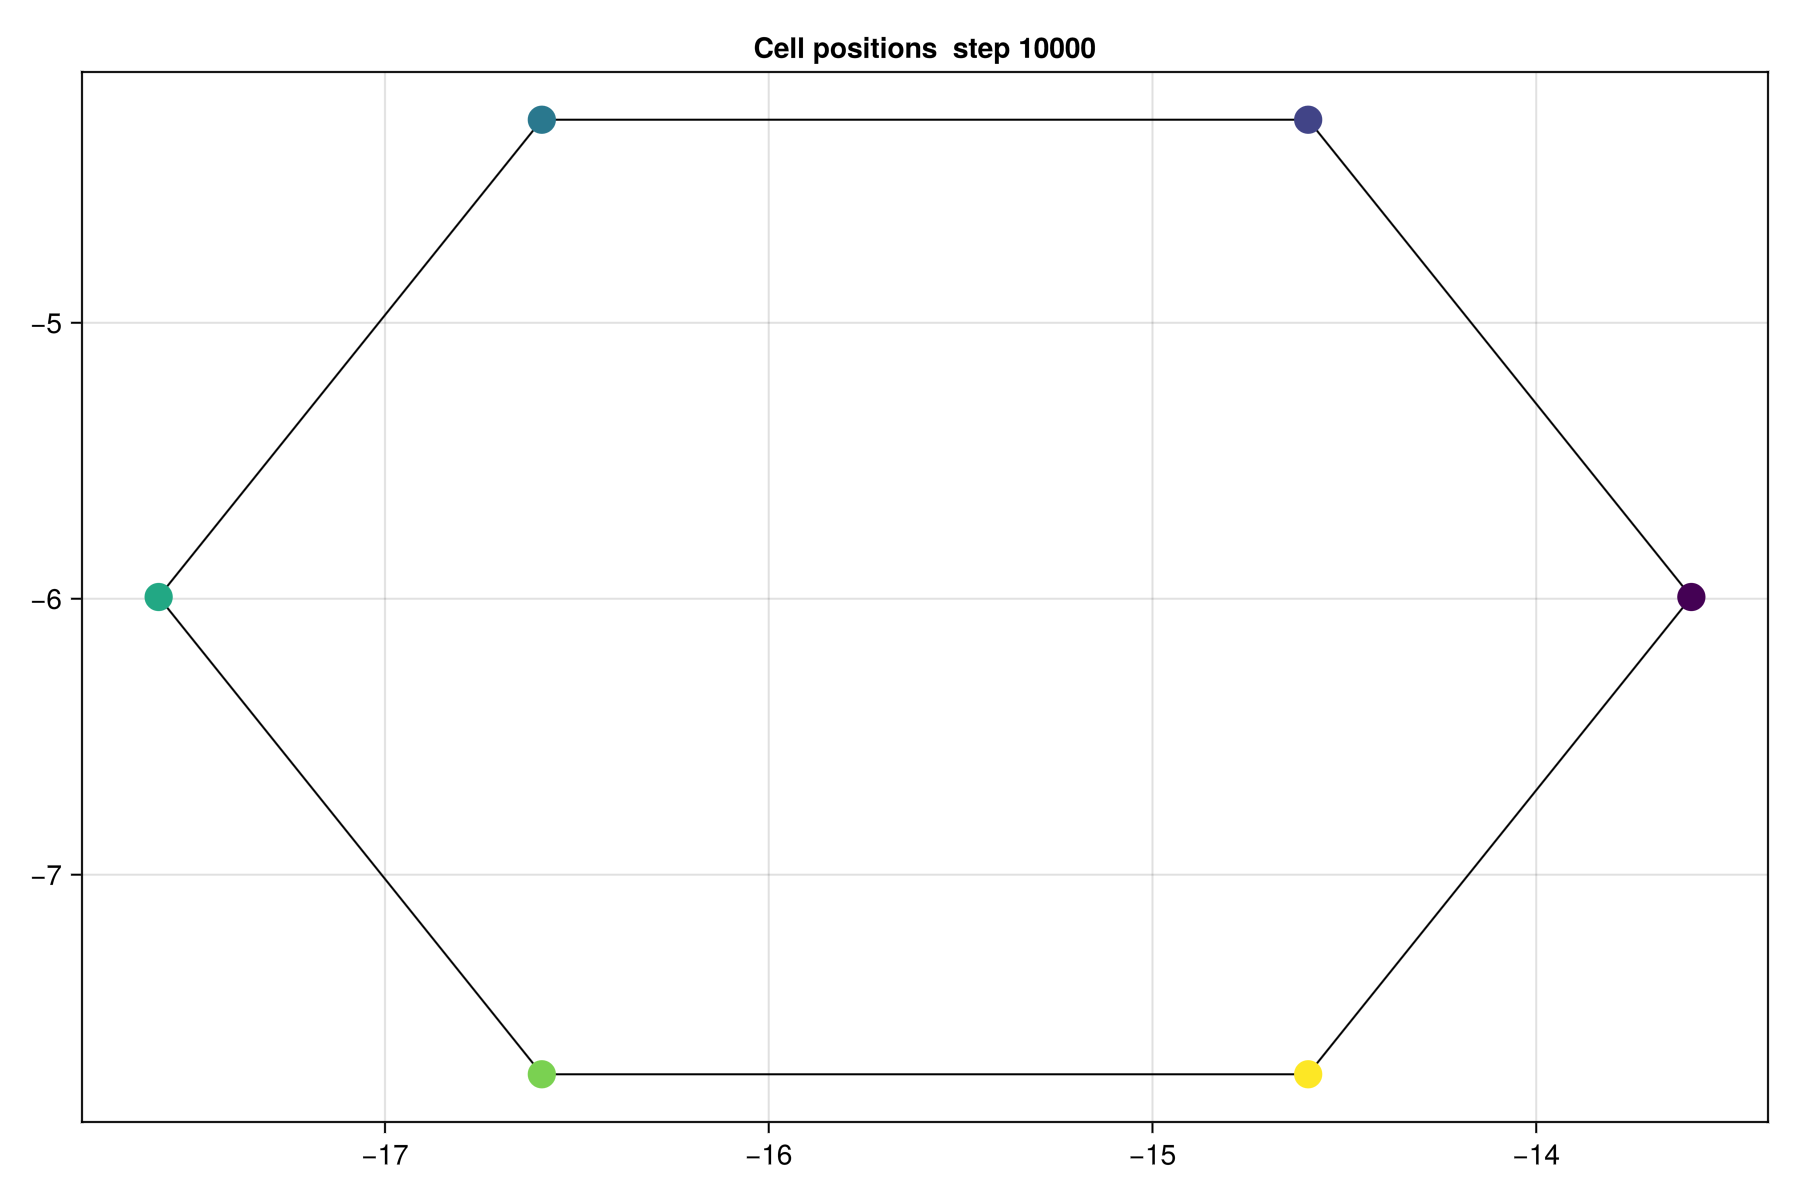

GLMakie.Screen(...)

In [241]:
fig = Figure(size = (900,600))
ax = Axis(fig[1,1], title ="Cell positions  step 10000")

jldopen("bead_spring.jld2", "r") do file
        g = file[@sprintf("step_%06d", 50)]     #Plot carrega les posicions de totes les cèl·lules en un punt concret. 

        x = g["x"]
        y = g["y"]
        group = g["group"]  
        bead_id = g["bead_id"]

        for grp in unique(group)

                for (i, j) in GROUP_CONNECTIONS[grp]

                        idx_i = findfirst((group .== grp) .& (bead_id .== i))
                        idx_j = findfirst((group .== grp) .& (bead_id .== j))

                        r = sqrt((x[idx_i]-x[idx_j])^2 + (y[idx_i]-y[idx_j])^2)
                        lw = 1 + 5*abs(r - 2)

                        lines!(ax, [x[idx_i], x[idx_j]], [y[idx_i], y[idx_j]], linewidth = lw, color = :black)
                end
        end

        scatter!(ax, x, y, markersize = 20, color = bead_id)
end
display(fig)


